The Dolinar receiver we divide our pulse (for example a laser) into infinitesimals slices and adjust continuously and the Local Oscillator amplitude $\beta(t)$ based on the detected photons with feedback in real time, making the error limit of Helstrom saturated.

We'll use a beam splitter so I'll try to do it again to see if it works.

$$\begin{pmatrix} \alpha_1' \\ \alpha_2' \end{pmatrix} = BS(T) \begin{pmatrix} \alpha_1 \\ \alpha_2 \end{pmatrix}$$

$$
 = \begin{pmatrix} \sqrt{T} & \sqrt{R}e^{i\phi} \\ -\sqrt{R}e^{-i\phi} & \sqrt{T} \end{pmatrix} \begin{pmatrix} \alpha_1 \\ \alpha_2 \end{pmatrix}
$$

In [ ]:
import numpy as np
from scipy.special import erfc
import matplotlib.pyplot as plt



def beam_splitter(alpha_1, alpha_2, T, phi=0.0):  #function to calculate the exits of a loss free beam-splitter
                                                          # alpha_1 and alpha_2 are complex or float
                                                          #T is float
                                                          #phi is float  (radian)    

    if not (0.0 <= T <= 1.0):
        raise ValueError("Error, transmittance has to be in the interval from 0 to 1")  #Since the transmittance varies from 0 to 1,
                                                                                   #we should get error if it's different
        
    R = 1.0 - T  #reflectivity
    
    # Beam Splitter operator
    U_bs = np.array([
        [np.sqrt(T),               np.sqrt(R) * np.exp(1j * phi)],
        [-np.sqrt(R) * np.exp(-1j * phi), np.sqrt(T)            ]
    ], dtype=complex)
    
    in_vector = np.array([alpha_1, alpha_2], dtype=complex)  # input vectors
    out_vector = U_bs @ in_vector   #Output after the beam splitter
    
    alpha_1_out, alpha_2_out = out_vector[0], out_vector[1]
    return alpha_1_out, alpha_2_out



In [6]:
def spd_detector(field_amplitude):  #detecting one ideal photon, creating the "clicks" through the Poisson distribution
  
    mean_photons = np.abs(field_amplitude)**2
    photons = np.random.poisson(mean_photons)
    return 1 if photons > 0 else 0

We start with 50/50% of probability and everytime we get new information we have a probability of updating like to 49/51%. 
Everytime we get a information from the measurements we update the probability of the measurements like P(bit=0 | k).
Implementing:

In [15]:
def bayes_update(p0, k, hyp0, hyp1, beta):
    det_0 = hyp0 + beta #Field in the detector to the possibility of detecting +alpha
    det_1 = hyp1 + beta #Field in the detector to the possibility of detecting -alpha
    
    p_k_given_0 = np.exp(-np.abs(det_0)**2) if k == 0 else (1.0 - np.exp(-np.abs(det_0)**2))   #probability of click given hypothesis 0
    p_k_given_1 = np.exp(-np.abs(det_1)**2) if k == 0 else (1.0 - np.exp(-np.abs(det_1)**2))   #probability of click given hypothesis 1
    
    den = p_k_given_0 * p0 + p_k_given_1 * (1.0 - p0)
    p0_post = (p_k_given_0 * p0) / (den + 1e-15)
    return float(np.clip(p0_post, 1e-12, 1.0 - 1e-12))

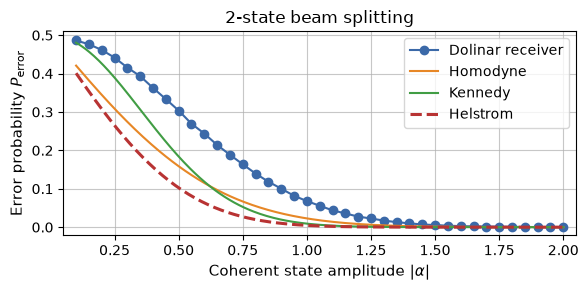

In [20]:
def simulate_single_trial(alpha_in, T_split=0.5):  #Dolinar circuit with 2 stages, with the beam splitter function and feedback
    tx_bit = np.random.choice([0, 1])
    s_in = alpha_in if tx_bit == 0 else -alpha_in
    
    # BS 1 (50:50)
    s_slice1, s_slice2 = beam_splitter(s_in, 0.0 + 0.0j, T=T_split)  #First slice of the signal and second slice of the signal after the beam splitter
    hyp0_s1, hyp0_s2 = beam_splitter(alpha_in, 0.0 + 0.0j, T=T_split)
    hyp1_s1, hyp1_s2 = beam_splitter(-alpha_in, 0.0 + 0.0j, T=T_split)
    
    # 1st stage (no feedback)
    p0 = 0.5
    beta1 = -hyp1_s1 if p0 >= 0.5 else -hyp0_s1
    k1 = spd_detector(s_slice1 + beta1)
    p0_post1 = bayes_update(p0, k1, hyp0_s1, hyp1_s1, beta1)
    
    # 2nd stage (with feedback)
    beta2 = -hyp1_s2 if p0_post1 >= 0.5 else -hyp0_s2
    k2 = spd_detector(s_slice2 + beta2)
    p0_final = bayes_update(p0_post1, k2, hyp0_s2, hyp1_s2, beta2)
    
    decision = 0 if p0_final >= 0.5 else 1
    return tx_bit, decision


# curves for the theoretical bounds
def helstrom_bound(alpha):
    return 0.5 * (1.0 - np.sqrt(1.0 - np.exp(-4.0 * (alpha**2))))

def kennedy_bound(alpha):
    return 0.5 * np.exp(-4.0 * (alpha**2))

def homodyne_receiver(alpha):
    return 0.5 * erfc(np.sqrt(2.0) * alpha)


# Monte Carlo simulation parameters
alphas = np.linspace(0.1, 2.0, 39)
n_trials = 100_000
sim_ber = []

for a in alphas:
    errors = 0
    for _ in range(n_trials):
        tx, rx = simulate_single_trial(alpha_in=a, T_split=0.5)
        if tx != rx:
            errors += 1
    sim_ber.append(errors / n_trials)

alpha_dense = np.linspace(0.1, 2.0, 300)


#plots
plt.figure(figsize=(6, 3))
plt.plot(alphas, sim_ber, 'o-', color='#3b69a8', label='Dolinar receiver', markersize=6)
plt.plot(alpha_dense, homodyne_receiver(alpha_dense), '-', color="#e78726", label='Homodyne ')
plt.plot(alpha_dense, kennedy_bound(alpha_dense), '-', color='#419d44', label='Kennedy ')
plt.plot(alpha_dense, helstrom_bound(alpha_dense), '--', color= '#b83333', linewidth=2.2, label='Helstrom ')

plt.title('2-state beam splitting', fontsize=12)
plt.xlabel(r'Coherent state amplitude $|\alpha|$', fontsize=11)
plt.ylabel(r'Error probability $P_{\mathrm{error}}$', fontsize=11)
plt.grid(True, which='major', linestyle='-', alpha=0.7)
plt.legend(fontsize=10, loc='upper right')
plt.xlim(0.05, 2.05)
plt.ylim(-0.02, 0.51)
plt.tight_layout()
plt.show()

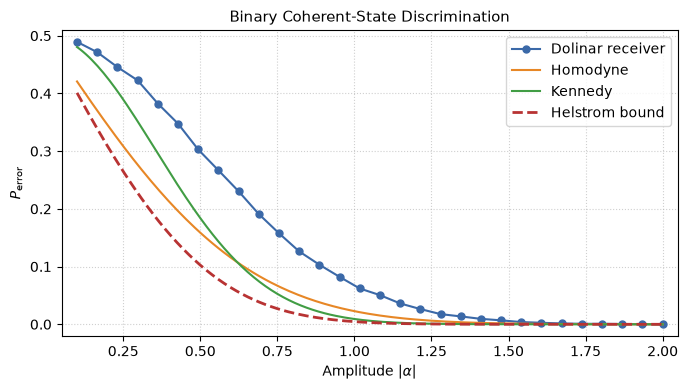

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import erfc

def dolinar_trial(alpha, n_slices=30):  #Divided pulse with feedback
    tx_bit = np.random.choice([0, 1])
    s = (alpha if tx_bit == 0 else -alpha) * np.sqrt(1.0 / n_slices)
    a = alpha * np.sqrt(1.0 / n_slices)
    
    p0 = 0.5  # Probability
    for _ in range(n_slices):
        # LO of Dolinar dependent of posteriori probability
        beta = a if p0 >= 0.5 else -a
        
        # 1 photon detection (Poisson)
        k = 1 if np.random.poisson(np.abs(s + beta)**2) > 0 else 0
        
        # Bayesian update
        p_k0 = np.exp(-np.abs(a + beta)**2) if k == 0 else 1.0 - np.exp(-np.abs(a + beta)**2)
        p_k1 = np.exp(-np.abs(-a + beta)**2) if k == 0 else 1.0 - np.exp(-np.abs(-a + beta)**2)
        
        p0 = (p_k0 * p0) / (p_k0 * p0 + p_k1 * (1.0 - p0) + 1e-15)
        
    return tx_bit != (0 if p0 >= 0.5 else 1)

# Theoretical bounds
helstrom = lambda a: 0.5 * (1.0 - np.sqrt(1.0 - np.exp(-4.0 * (a**2))))
kennedy  = lambda a: 0.5 * np.exp(-4.0 * (a**2))
homodyne = lambda a: 0.5 * erfc(np.sqrt(2.0) * a)

# Monte Carlo
alphas = np.linspace(0.1, 2.0, 30)
ber = [np.mean([dolinar_trial(a) for _ in range(20_000)]) for a in alphas]
a_fine = np.linspace(0.1, 2.0, 200)

# Graphic
plt.figure(figsize=(7, 4))
plt.plot(alphas, ber, 'o-', color='#3b69a8', label='Dolinar receiver', markersize=5)
plt.plot(a_fine, homodyne(a_fine), '-', color='#e78726', label='Homodyne')
plt.plot(a_fine, kennedy(a_fine), '-', color='#419d44', label='Kennedy')
plt.plot(a_fine, helstrom(a_fine), '--', color='#b83333', linewidth=2, label='Helstrom bound')

plt.title('Binary Coherent-State Discrimination', fontsize=11)
plt.xlabel(r'Amplitude $|\alpha|$')
plt.ylabel(r'$P_{\mathrm{error}}$')
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend()
plt.xlim(0.05, 2.05)
plt.ylim(-0.02, 0.51)
plt.tight_layout()
plt.show()